In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Гиперпараметры и оптимизация

обучить MLP на NumPy так, чтобы он воспроизводил синусоиду на отрезке 
$[−2π, 2π]$


- *Реализуете step decay и посмотрите, как скорость спада lr влияет на скорость и качество сходимости.*
- *Внедрите Reduce on Plateau, чтобы lr автоматически снижался при «застревании» на плато валидационных потерь.*
- *Напишете метод update_adagrad(lr) и сравните адаптивный шаг с фиксированными стратегиями.*
- *Добавите update_adamw(lr), чтобы оценить преимущества decoupled weight decay при сложном ландшафте функции потерь.*


# AdamW

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

class MLP:
    def __init__(self, layer_sizes, activation='tanh'):
        self.epsilon = 1e-8  # Маленькая константа для избежания деления на ноль
        self.weight_decay = 1e-4  # Decoupled weight decay
        # Счётчик итераций для Adam
        self.iterations = 0
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.W, self.b = [], []
        self.Z_list, self.A_list = [], []
        self.dW_list, self.db_list = [], []
        # Добавим накопители моментов
        # Добавим параметры Adam beta1, beta2
        self.mW, self.vW, self.mb, self.vb = [], [], [], []
        self.beta1, self.beta2 = 0.9, 0.999 
        

        for i in range(len(layer_sizes)-1):
            in_dim, out_dim = layer_sizes[i], layer_sizes[i+1]
            self.W.append(np.random.randn(in_dim, out_dim) * np.sqrt(2/(in_dim + out_dim)))
            self.b.append(np.zeros((1, out_dim)))
            # Инициализация накопителей

            # Adam moments for weights
            self.mW.append(np.zeros((in_dim, out_dim)))
            self.vW.append(np.zeros((in_dim, out_dim)))

            # Adam moments for biases
            self.mb.append(np.zeros((1, out_dim)))
            self.vb.append(np.zeros((1, out_dim)))

    def _activate(self, Z):
        if self.activation == 'sigmoid':
            return 1/(1+np.exp(-Z))
        elif self.activation == 'relu':
            return np.maximum(0, Z)
        elif self.activation == 'tanh':
            return np.tanh(Z)
        else:
            raise ValueError(self.activation)

    def _dactivate(self, Z):
        if self.activation == 'sigmoid':
            s = 1/(1+np.exp(-Z)); return s*(1-s)
        elif self.activation == 'relu':
            return (Z > 0).astype(float)
        elif self.activation == 'tanh':
            return 1 - np.tanh(Z)**2

    def forward(self, X):
        self.Z_list, self.A_list = [], []
        A = X
        self.A_list.append(A)
        for i in range(len(self.W)):
            Z = A.dot(self.W[i]) + self.b[i]
            self.Z_list.append(Z)
            A = self._activate(Z) if i < len(self.W)-1 else Z
            self.A_list.append(A)
        return A

    def mse(self, y_pred, y_true):
        return np.mean((y_pred - y_true)**2)

    def backward(self, y_true):
        m = y_true.shape[0]
        # Выходной слой (линейная активация, производная = 1)
        aL, zL = self.A_list[-1], self.Z_list[-1]
        delta = (2*(aL - y_true)/m)
        # Градиенты выхода
        a_prev = self.A_list[-2]
        dW = a_prev.T.dot(delta)
        db = np.sum(delta, axis=0, keepdims=True)
        self.dW_list, self.db_list = [dW], [db]
        # Скрытые слои (используем производную активации)
        for l in range(len(self.layer_sizes)-2, 0, -1):
            z = self.Z_list[l-1]
            a_prev = self.A_list[l-1]
            W_next = self.W[l]
            delta = delta.dot(W_next.T) * self._dactivate(z)
            dW = a_prev.T.dot(delta)
            db = np.sum(delta, axis=0, keepdims=True)
            self.dW_list.insert(0, dW)
            self.db_list.insert(0, db)


    def update_adamw(self, lr):
        self.iterations += 1
        t = self.iterations

        for i in range(len(self.W)):
            gW = self.dW_list[i]
            gb = self.db_list[i]

            self.mW[i] = self.beta1 * self.mW[i] + (1 - self.beta1) * gW
            self.mb[i] = self.beta1 * self.mb[i] + (1 - self.beta1) * gb

            self.vW[i] = self.beta2 * self.vW[i] + (1 - self.beta2) * (gW ** 2)
            self.vb[i] = self.beta2 * self.vb[i] + (1 - self.beta2) * (gb ** 2)

            mW_hat = self.mW[i] / (1 - self.beta1 ** t)
            mb_hat = self.mb[i] / (1 - self.beta1 ** t)

            vW_hat = self.vW[i] / (1 - self.beta2 ** t)
            vb_hat = self.vb[i] / (1 - self.beta2 ** t)

            self.W[i] -= lr * self.weight_decay * self.W[i]

            self.W[i] -= lr * mW_hat / (np.sqrt(vW_hat) + self.epsilon)
            self.b[i] -= lr * mb_hat / (np.sqrt(vb_hat) + self.epsilon)

# Разбиваем на train/val
perm = np.random.permutation(len(X))
split = int(0.8 * len(X))
X_train, y_train = X[perm[:split]], y[perm[:split]]
X_val,   y_val   = X[perm[split:]], y[perm[split:]]

# Инициализация модели
mlp = MLP([1, 50, 1], activation='tanh')

# Параметры обучения и Reduce on Plateau
initial_lr = 0.01
lr = initial_lr
patience = 20
best_val_loss = np.inf
wait = 0
epochs = 500

train_loss_history = []
val_loss_history   = []

for epoch in range(1, epochs+1):
    # тренировка на всём train
    preds_train = mlp.forward(X_train)
    train_loss = mlp.mse(preds_train, y_train)
    train_loss_history.append(train_loss)

    mlp.backward(y_train)
    mlp.update_adamw(lr)

    # оценка на валидации
    preds_val = mlp.forward(X_val)
    val_loss = mlp.mse(preds_val, y_val)
    val_loss_history.append(val_loss)

    #  Reduce on Plateau
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            lr *= 0.5
            wait = 0
            print(f"Epoch {epoch}: val_loss plateaued, new lr = {lr:.5f}")

    if epoch % 200 == 0:
        print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, lr={lr:.5f}")

# График финальной аппроксимации
preds_all = mlp.forward(X)
idx = np.argsort(X.flatten())
plt.figure(figsize=(6,4))
plt.scatter(X, y, s=10, alpha=0.5, label='Данные')
plt.plot(X.flatten()[idx], preds_all.flatten()[idx],
         color='red', linewidth=2, label='MLP AdamW Approximation')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Аппроксимация sin(x)')
plt.legend()
plt.grid(True)
plt.show()

IndentationError: expected an indented block after function definition on line 85 (713882356.py, line 91)

# 2. Reg L1/L2

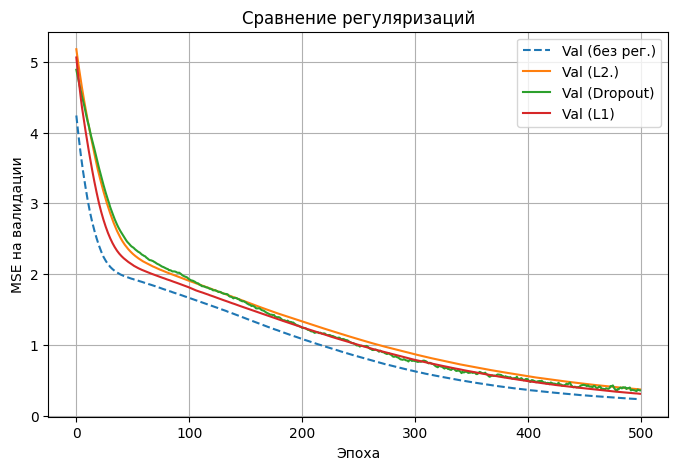

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)



import numpy as np


# Мало данных — всего 50 точек на отрезке [-2, 2]
np.random.seed(0)
# Задача посложнее — синус с шумом
X = np.linspace(-2, 2, 50)[:, None]
y = X**3 - X + 0.1 * np.random.randn(*X.shape)
perm = np.random.permutation(len(X))
split = int(0.8 * len(X))


# Разделим на тренировочную и валидационную выборки
X_train, y_train = X[perm[:split]], y[perm[:split]]
X_val,   y_val   = X[perm[split:]], y[perm[split:]]

class MLP:
    def __init__(self,
                 layer_sizes,
                 activation='relu',
                 lr=0.01,
                 l2=0.0,      # здесь мы будем задавать параметр L2
                 l1=0.0,      # здесь будем задавать параметр L1
                 dropout=0.0  # здесь будем задавать Dropout
                ):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.W, self.b = [], []
        self.Z_list, self.A_list = [], []
        self.dW_list, self.db_list = [], []
        self.lr = lr
        self.l2 = l2
        self.l1 = l1
        self.dropout = dropout

        for i in range(len(layer_sizes)-1):
            in_dim, out_dim = layer_sizes[i], layer_sizes[i+1]
            self.W.append(np.random.randn(in_dim, out_dim) * np.sqrt(2/(in_dim + out_dim)))
            self.b.append(np.zeros((1, out_dim)))

        # контейнер для масок Dropout (скрытые слои)
        self.masks = [None] * (len(self.W)-1)

    def _activate(self, Z):
        if self.activation == 'sigmoid':
            return 1/(1+np.exp(-Z))
        elif self.activation == 'relu':
            return np.maximum(0, Z)
        elif self.activation == 'tanh':
            return np.tanh(Z)
        else:
            raise ValueError(self.activation)

    def _dactivate(self, Z):
        if self.activation == 'sigmoid':
            s = 1/(1+np.exp(-Z))
            return s*(1-s)
        elif self.activation == 'relu':
            return (Z > 0).astype(float)
        elif self.activation == 'tanh':
            return 1 - np.tanh(Z)**2
        else:
            raise ValueError(self.activation)

    def forward(self, X, train=True):
        self.Z_list, self.A_list = [], []
        A = X
        self.A_list.append(A)
        #     self.Z_list.append(Z)
        # выходной слой (линейный)
        for i in range(len(self.W)):
            Z = A.dot(self.W[i]) + self.b[i]
            self.Z_list.append(Z)
            A = self._activate(Z) if i < len(self.W)-1 else Z
            if train and self.dropout > 0 and i < len(self.W)-1:
                mask = (np.random.rand(*A.shape) > self.dropout) / (1 - self.dropout)
                A *= mask
                self.masks[i] = mask
            self.A_list.append(A)
        return A

    def mse(self, y_pred, y_true):
        loss = np.mean((y_pred - y_true)**2)
        loss += (self.l2/2) * sum(np.sum(W*W) for W in self.W)
        # Добавьте L1-регуляризацию
        # Ваш код здесь
        return loss
    
    def backward(self, y_true):
        m = y_true.shape[0]
        # Выходной слой (линейный)
        aL, zL = self.A_list[-1], self.Z_list[-1]
        delta = (2*(aL - y_true)/m)

        # Градиенты выхода
        a_prev = self.A_list[-2]
        # Добавьте L1-регуляризацию к градиентам
        dW = a_prev.T.dot(delta) + self.l2 * self.W[-1] + self.l1 * np.sign(self.W[-1])
        db = np.sum(delta, axis=0, keepdims=True)
        self.dW_list, self.db_list = [dW], [db]

        # Скрытые слои (используем производную активации)
        for l in range(len(self.layer_sizes)-2, 0, -1):
            z = self.Z_list[l-1]
            a_prev = self.A_list[l-1]
            W_next = self.W[l]
            delta = delta.dot(W_next.T) * self._dactivate(z)
    
            if self.dropout > 0:
                delta *= self.masks[l-1]
            # Добавьте L1-регуляризацию к градиентам        
            dW = a_prev.T.dot(delta) + self.l2 * self.W[l-1] + self.l1 * np.sign(self.W[l-1])
            db = np.sum(delta, axis=0, keepdims=True)
            self.dW_list.insert(0, dW)
            self.db_list.insert(0, db)

    def update_params(self):
        for i in range(len(self.W)):
            self.W[i] -= self.lr * self.dW_list[i]
            self.b[i] -= self.lr * self.db_list[i]

# Функция обучения и сбора кривых loss
def train_model(model, epochs=500):
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        # train
        preds = model.forward(X_train, train=True)
        train_losses.append(model.mse(preds, y_train))
        model.backward(y_train)
        model.update_params()
        # val
        preds_val = model.forward(X_val, train=False)
        val_losses.append(model.mse(preds_val, y_val))
    return train_losses, val_losses

# Пример использования:
m0 = MLP([1,64,64,1], lr=0.01, l2=0.00,    l1=0,    dropout=0.0)  # без регуляризации
m1 = MLP([1,64,64,1], lr=0.01, l2=0.001,    l1=0,    dropout=0.0)  # L2-регуляризация
m2 = MLP([1,64,64,1], lr=0.01, l2=0.00,    l1=0,    dropout=0.1)  # Dropout
m3 = MLP([1,64,64,1], lr=0.01, l2=0.00,    l1=0.001,    dropout=0.0)  # L1-регуляризация

l0, v0 = train_model(m0)
l1, v1 = train_model(m1)
l2, v2 = train_model(m2)
l3, v3 = train_model(m3)


# Построение сравнительных кривых
plt.figure(figsize=(8,5))
plt.plot(v0, '--', label='Val (без рег.)')
plt.plot(v1, label='Val (L2.)')
plt.plot(v2, label='Val (Dropout)')
plt.plot(v3, label='Val (L1)')

plt.xlabel('Эпоха')
plt.ylabel('MSE на валидации')
plt.title('Сравнение регуляризаций')
plt.legend()
plt.grid(True)
plt.show()